# Small-Scale Experiments

### Imports


In [1]:
import cupy
import matplotlib.pyplot as plt
import numpy as np
import s3fs
import zarr

from cupyx.scipy.ndimage import (
    gaussian_laplace as cupy_gaussian_laplace,
    maximum_filter as cupy_maximum_filter,
)
from deep_neurographs.utils import img_util, swc_util, util
from scipy import ndimage as ndi
from scipy.ndimage import gaussian_laplace, gaussian_filter, maximum_filter, center_of_mass
from skimage.feature import peak_local_max
from skimage.measure import label
from skimage.segmentation import watershed
from time import time

%matplotlib inline

IMG_PREFIX = {
    "685221": "exaSPIM_685221_2024-04-12_11-46-38_fusion_2024-07-22_21-00-15",
    "703070": "exaSPIM_703070_2024-07-09_12-52-33_flatfield-correction_2024-07-18_12-43-27_fusion_2024-08-02_17-11-59",
    "706301": "exaSPIM_706301_2024-04-23_11-24-24_fusion_2024-05-21_00-00-03",
    "708369": "exaSPIM_708369_2024-04-08_15-20-36_fusion_2024-05-20_23-30-43",
    "709393": "exaSPIM_709393_2024-04-17_09-37-51_fusion_2024-07-27_00-20-20",
    "715345": "exaSPIM_715345_2024-06-07_10-03-37_fusion_2024-07-02_10-30-40"
}

In [2]:
# Subroutines
def rescale(arr, clip_bool=True):
    if clip_bool:
        arr = np.clip(arr, 0, np.percentile(arr, 99.99))
    arr -= np.min(arr)
    arr = (2**16 - 1) * (arr / np.max(arr))
    return (arr).astype(np.uint16)


def get_mip(arr, axis=0, clip_bool=False):
    mip = np.max(arr, axis=axis)
    mip = rescale(mip, clip_bool=clip_bool)
    return mip


def get_img_patch(img, voxel, shape, from_center=True):
    start, end = img_util.get_start_end(voxel, shape, from_center=from_center)
    return img[0, 0, start[2]:end[2], start[1]:end[1], start[0]:end[0]]


def plot_mips(volume, prefix="", clip_bool=True):
    fig, axs = plt.subplots(1, 3, figsize=(10, 4))
    axs_names = ["XY", "XZ", "YZ"]
    for i in range(3):
        axs[i].imshow(get_mip(volume, axis=i, clip_bool=clip_bool))
        axs[i].set_title(prefix + axs_names[i], fontsize=16)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
    plt.tight_layout()
    plt.show()


def mark_voxel(img_patch, voxel):
    i, j, k = voxel
    img_patch[i-2:i+1, j-2:j+1, k-2:k+1] = np.max(img_patch) + 500
    return img_patch



### Opem img

In [3]:
# Parameters
s3_bucket = "aind-open-data"
dataset = "706301"
downsample_factor = 4

# Initializations
fs = s3fs.S3FileSystem()
s3_url = f"s3://{s3_bucket}/{IMG_PREFIX[dataset]}/fused.zarr/{downsample_factor}/"

# Open img
store = s3fs.S3Map(root=s3_url, s3=fs)
img = zarr.open(store, mode='r')
print("img.shape:", img.shape)

img.shape: (1, 1, 1812, 1821, 3895)


  0%|          | 11/12960 [00:32<10:30:16,  2.92s/it]


### Read img

In [4]:
traceable_somas = [
    [18403.324, 11245.411, 2675.9985],
    [23425.596, 8926.942, 2185.401],
    [18400.334,11231.872,2683.3584],
    [21624.133,7740.173,12768.359],
    [22883.316,4323.8574,16284.648],
    [43937.27,5479.154,12344.152],
]

bright_nonsomas = [
    [20026.29,6470.747,14384.427],
    [18330.354,3822.579,14477.964],
    [22800.148,2251.1611,16850.379],
    [37846.895,6913.5713,20431.992],
    [43469.51,4820.5303,16769.32],
    [44225.082,4402.9487,15589.198],
    [22086.203,16967.01,14625.586],
    [20239.145,21295.611,11517.228],
]

Voxel: [1923  371 1013]
# Objects Detected: 1


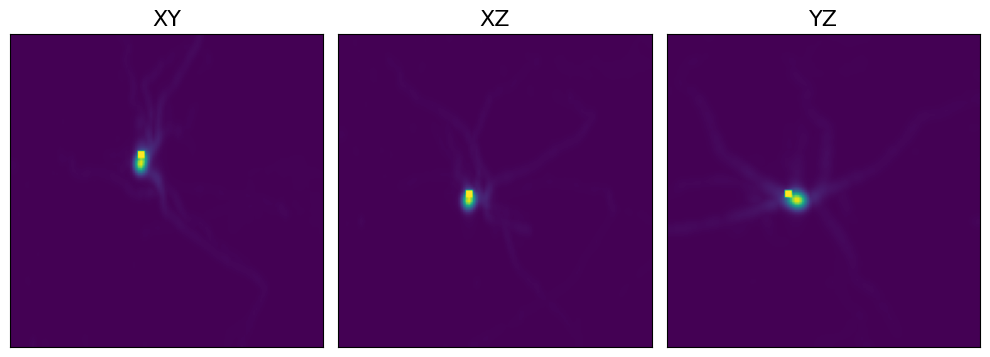

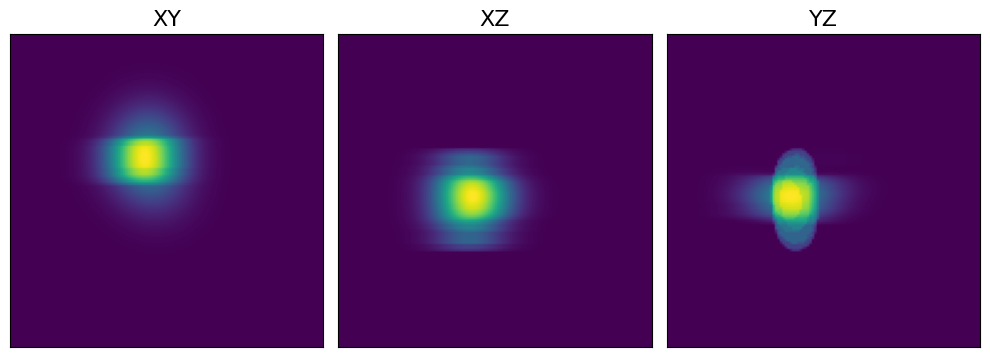

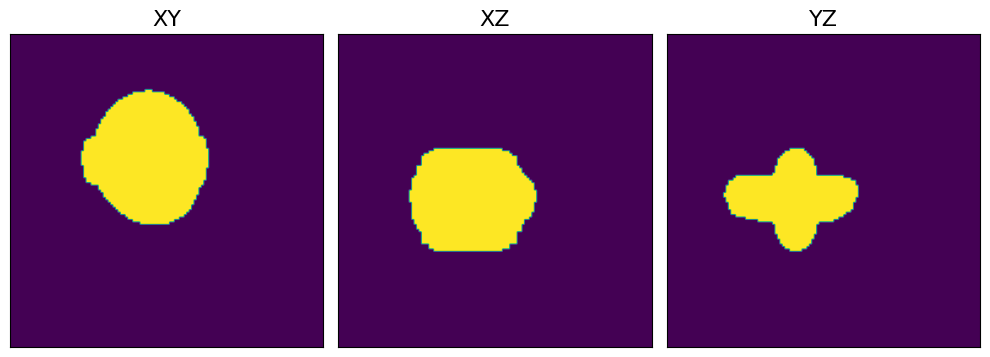

In [5]:
# Region of interest
idx = 4
shape = [128, 128, 128]
from_center = True

# Read img
voxel = img_util.to_voxels([23011.997526077983, 4437.8754730383, 16202.112257081515], downsample_factor=downsample_factor)
img_chunk = get_img_patch(img, voxel, shape, from_center=from_center)
print("Voxel:", voxel)

# Smooth with Gaussian Filter
img_chunk = gaussian_filter(img_chunk, [2, 2, 1])

# Compute LoG
log_img = gaussian_laplace(img_chunk, 10)  # use 6 to detect somas of dim neurons

# Find blob centroids
labels, n_labels = label(log_img > 2000, return_num=True)
centers = center_of_mass(img_chunk, labels=labels, index=np.arange(1, n_labels+1))
candidates = list()
for center in centers:
    if img_chunk[tuple([int(c) for c in center])] > 0:
        img_chunk = mark_voxel(img_chunk, tuple([int(c) for c in center]))
        candidates.append(center)

# Plot mips
print("# Objects Detected:", len(candidates))
plot_mips(img_chunk)
plot_mips(log_img)
plot_mips(labels)


## Large-Scale Experiment

In [15]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

import os
import random


def sliding_window_coords_3d(image, window_size, overlap):
    # Calculate the stride based on the overlap and window size
    stride = tuple(w - o for w, o in zip(window_size, overlap))
    
    # Get dimensions of the image and window
    _, _, z_dim, y_dim, x_dim = image.shape
    z_win, y_win, x_win = window_size
    z_stride, y_stride, x_stride = stride

    # Loop over the image with the sliding window
    coords = []
    for x in range(0, x_dim - x_win + 1, x_stride):
        for y in range(0, y_dim - y_win + 1, y_stride):
            for z in range(0, z_dim - z_win + 1, z_stride):
                coords.append((x, y, z))
    return coords


def find_candidates(img, coord, window_size):
    # Read image patch
    img_patch = get_img_patch(img, coord, window_size, from_center=False)
    if np.max(img_patch) < 200:
        return list()

    # Find blobs
    img_patch = gaussian_filter(img_patch, [2, 2, 1.0])
    labels, k = label(gaussian_laplace(img_patch, 10) > 100, return_num=True)

    # Compute blob centroids
    if k > 0:
        index = np.arange(1, k + 1)
        centers = center_of_mass(img_patch, labels=labels, index=index)
    else:
        centers = list()
    return filter_centers(img_patch, centers, coord)


def filter_centers(img_patch, centers, offset):
    filtered_centers = list()
    for center in centers:
        voxel = tuple([int(c) for c in center])
        if img_patch[voxel] > 200:
            xyz = local_voxel_to_physical(center[::-1], offset)
            filtered_centers.append(xyz)
    return filtered_centers


def local_voxel_to_physical(local_voxel, offset):
    global_voxel = np.array([v + o for v, o in zip(local_voxel, offset)])
    return img_util.to_world(global_voxel * 2 ** downsample_factor)


### Soma Candidate Detection

In [14]:
# Parameters
window_size = (128, 128, 128)
overlap = (32, 32, 32)

# Initializations
coords = sliding_window_coords_3d(img, window_size, overlap)
output_dir = "/root/capsule/results/soma_candidates"
util.mkdir(output_dir, delete=True)
print("# img patches:", len(coords))

# Detection
with ThreadPoolExecutor() as executor:
    threads = list()
    for coord in coords: #random.sample(coords, 2000):
        threads.append(
            executor.submit(find_candidates, img, coord, window_size)
        )

    candidates = list()
    n_candidates = 0
    pbar = tqdm(total=len(threads))
    for thread in as_completed(threads):
        centers = thread.result()
        candidates.extend(centers)
        pbar.update(1)
print("# Candidates Detected:", len(candidates))

# Filter nearby candidates
with ThreadPoolExecutor() as executor:
    threads = list()
    for i, xyz in enumerate(candidates):
        path = os.path.join(output_dir, f"{i + 1}.swc")
        threads.append(
            executor.submit(
                swc_util.save_point, path, xyz, 10, color="1.0 0.0 0.0"
            )
        )

    pbar = tqdm(total=len(threads))
    for _ in as_completed(threads):
        pbar.update(1)


# img patches: 12960


  3%|▎         | 366/12960 [02:26<59:27,  3.53it/s]  

(2427.986755699206, 1902.888132310972, 27119.794244060104)


  3%|▎         | 437/12960 [02:51<1:53:17,  1.84it/s]

(2461.9430072410287, 7362.902212204026, 12737.887375077298)


...

 98%|█████████▊| 12712/12960 [56:32<00:26,  9.53it/s]

(44928.62823244309, 4015.4511191100446, 10890.4485624139)


100%|█████████▉| 12955/12960 [56:40<00:00, 44.00it/s]

# Candidates Detected: 659


NameError: name 'os' is not defined